# Excercise 2a: Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
X_train = pd.read_csv("ex2_train.csv")
y_train = pd.read_csv("ex2_class_train.csv")
data = X_train.copy()
data['Survived'] = y_train

In [3]:
data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,"Partner, Mr. Austen",male,45.5,0,0,28.5000,S,0
1,2,"Berriman, Mr. William John",male,23.0,0,0,13.0000,S,0
2,3,"Tikkanen, Mr. Juho",male,32.0,0,0,7.9250,S,0
3,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,7.8542,S,0
4,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,31.2750,S,0


This is a widely used dataset that contains information on the passengers who were aboard the Titanic when it sank on its maiden voyage in 1912. We will use it for a supervised learning exercise (ex2b) to predict whether a passenger can survive based on his or her attributes. Before constructing the classifier, you need to do some guided exploratory data analysis in ex2a.

The column meanings are: 
* Survived: Survival status (0 = No, 1 = Yes).
* Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd).
* Name: Name of the passenger.
* Sex: Gender of the passenger (male/female).
* Age: Age of the passenger in years.
* SibSp: Number of siblings/spouses aboard the Titanic.
* Parch: Number of parents/children aboard the Titanic.
* Fare: Passenger fare.
* Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

**TODO: Please answer the following questions by using suitable analysis tools, e.g. statistics or visualizations.** To pass the exercise, you need to correctly answer three or more of Questions 1 to 5. A correct answer includes a correct statement and the analysis result that support the statement.

# Example Question: Is gender related to survival rate?

Answer: Yes, females had a higher survival rate.

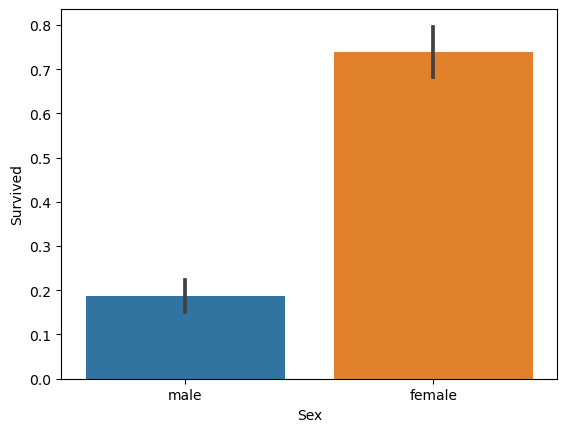

In [4]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Sex', y='Survived', data=data)
plt.show()

# Question 1: Did first-class passengers survive more?

Answer: Yes, passengers in first class had a significantly higher survival rate compared to second and third class.

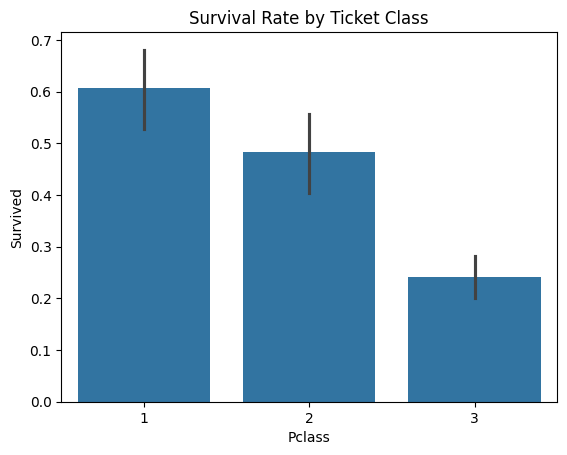

Pclass
1    0.607362
2    0.483444
3    0.241206
Name: Survived, dtype: float64


In [5]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Survival Rate by Ticket Class')
plt.show()

print(data.groupby('Pclass')['Survived'].mean())

# Question 2: Is survival related to Embarked?

Answer: Yes, passengers who embarked at Cherbourg (C) had the highest survival rate, followed by Queenstown (Q) and Southampton (S).

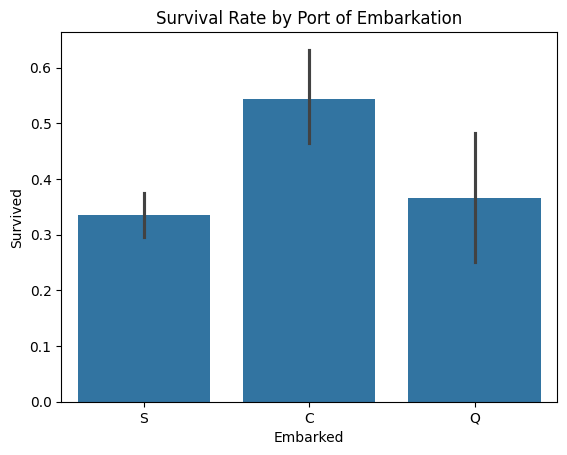

Embarked
C    0.544000
Q    0.366667
S    0.335238
Name: Survived, dtype: float64


In [6]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Embarked', y='Survived', data=data)
plt.title('Survival Rate by Port of Embarkation')
plt.show()

print(data.groupby('Embarked')['Survived'].mean())

# Question 3: How is age related to survival?

Answer: Young children (under 10-12 years) had a higher survival rate due to the "women and children first" protocol, whereas elderly passengers had lower survival rates.

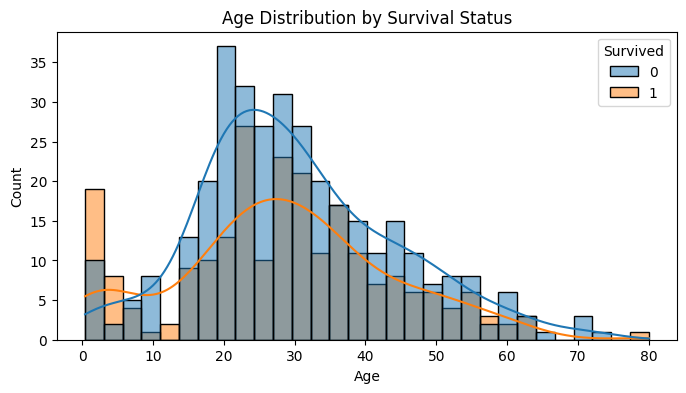

In [7]:
# Show the relevant statistics or visualization(s) to support your answer
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x='Age', hue='Survived', kde=True, bins=30)
plt.title('Age Distribution by Survival Status')
plt.show()

# Question 4: Does family size somehow affect the survival rate?

Answer: Yes. Passengers traveling in small families (family size of 2 to 4) had higher survival rates than passengers traveling alone or in large families (5 or more).

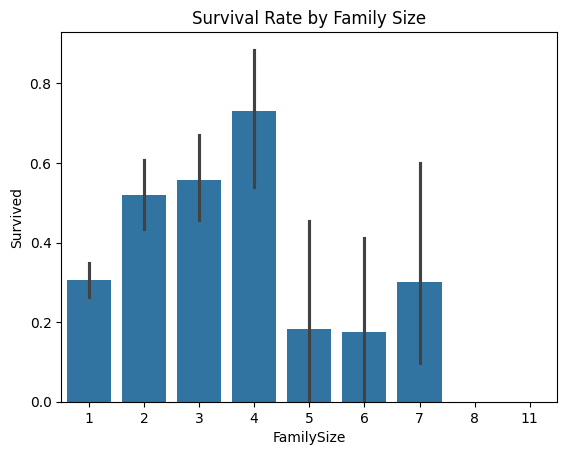

FamilySize
1     0.305361
2     0.519685
3     0.556962
4     0.730769
5     0.181818
6     0.176471
7     0.300000
8     0.000000
11    0.000000
Name: Survived, dtype: float64


In [8]:
# Show the relevant statistics or visualization(s) to support your answer
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

sns.barplot(x='FamilySize', y='Survived', data=data)
plt.title('Survival Rate by Family Size')
plt.show()

print(data.groupby('FamilySize')['Survived'].mean())

# Question 5: Some passengers with certain titles seemed to have more chance to survive. Is that true?

Answer: Yes, passengers with titles associated with women and higher social status (such as Mrs, Miss, Master, and noble titles) had significantly higher survival rates than adult men with the title Mr.

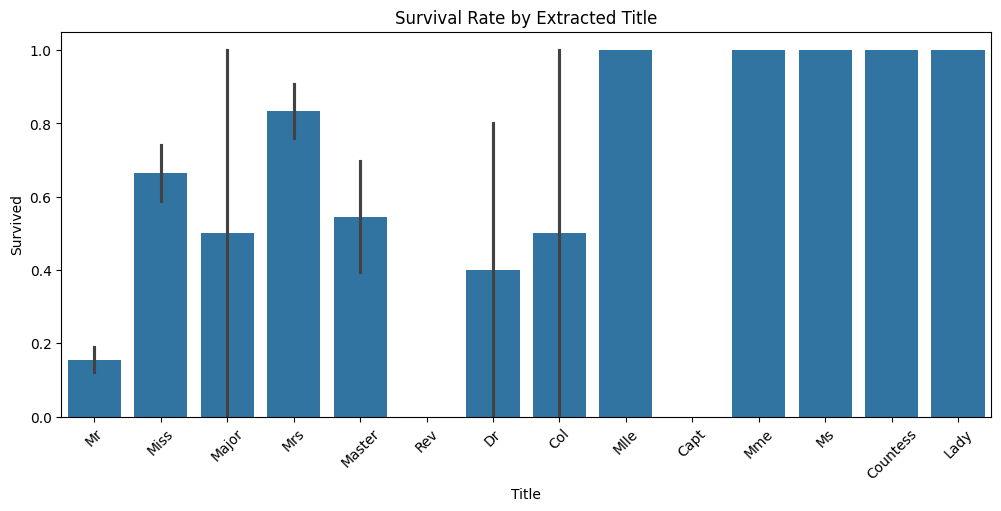

Title
Capt        0.000000
Col         0.500000
Countess    1.000000
Dr          0.400000
Lady        1.000000
Major       0.500000
Master      0.545455
Miss        0.664336
Mlle        1.000000
Mme         1.000000
Mr          0.155131
Mrs         0.833333
Ms          1.000000
Rev         0.000000
Name: Survived, dtype: float64


In [9]:
# Show the relevant statistics or visualization(s) to support your answer
data['Title'] = data['Name'].apply(lambda x: re.search(r' ([A-Za-z]+)\.', x).group(1))

plt.figure(figsize=(12, 5))
sns.barplot(x='Title', y='Survived', data=data)
plt.title('Survival Rate by Extracted Title')
plt.xticks(rotation=45)
plt.show()

print(data.groupby('Title')['Survived'].mean())